In [4]:
# Setup: imports, paths, EPW data, and simulation helper
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.home() / "Desktop/mold_risk_model"
EPW_DIR = BASE / "data/raw/epw"
FIG_DIR = BASE / "figures"
PROC_DIR = BASE / "data/processed"
FIG_DIR.mkdir(exist_ok=True)
PROC_DIR.mkdir(exist_ok=True)

# Load algorithm function (fallback to local definition if missing)
ALGO_DIR = BASE / "notebooks"
if str(ALGO_DIR) not in sys.path:
    sys.path.append(str(ALGO_DIR))

try:
    from hygro_algo import compute_moisture_index
except Exception as exc:
    print("Could not import hygro_algo; using local definitions:", exc)

    def rh_crit(temp_c):
        temp_c = np.asarray(temp_c, dtype=float)
        return np.where(temp_c < 0, 1.0,
               np.where(temp_c < 5, 0.95,
               np.where(temp_c < 10, 0.90,
               np.where(temp_c < 15, 0.85,
               np.where(temp_c < 20, 0.80,
               np.where(temp_c < 25, 0.75, 0.70))))))

    def e_sat(t):
        return 6.1078 * np.exp(17.27 * t / (t + 237.3))

    def surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct):
        e_out = (outdoor_rh_pct / 100.0) * e_sat(outdoor_temp_c)
        return np.clip(e_out / e_sat(surface_temp_c), 0.0, 1.0)

    def compute_moisture_index(surface_temp_c, outdoor_temp_c,
                               outdoor_rh_pct, dt_hours=1/60,
                               material="drywall"):
        sensitivity = {"drywall": 1.0, "wood": 0.8, "concrete": 0.5}
        k = sensitivity.get(material, 1.0)
        surface_temp_c = np.asarray(surface_temp_c, dtype=float)
        outdoor_temp_c = np.asarray(outdoor_temp_c, dtype=float)
        outdoor_rh_pct = np.asarray(outdoor_rh_pct, dtype=float)
        n = len(surface_temp_c)
        rh_surf = surface_rh(surface_temp_c, outdoor_temp_c, outdoor_rh_pct)
        rh_cr   = rh_crit(surface_temp_c)
        excess  = rh_surf - rh_cr
        mi = np.zeros(n)
        for i in range(1, n):
            if excess[i] > 0:
                mi[i] = mi[i-1] + k * excess[i] * dt_hours
            else:
                mi[i] = max(0.0, mi[i-1] + k * 0.1 * excess[i] * dt_hours)
        return {
            "rh_surface": rh_surf, "rh_crit": rh_cr,
            "exceedance": excess,  "mi": mi,
            "risk_score": np.clip(mi / 720.0 * 100, 0, 100),
            "alert":      mi > 24.0,
        }


def parse_epw(path):
    epw_cols = [
        "year","month","day","hour","minute",
        "data_source","dry_bulb_temp","dew_point_temp","rel_humidity",
        "atm_pressure","extraterr_horiz_rad","extraterr_direct_rad",
        "horiz_infrared_rad","global_horiz_rad","direct_normal_rad",
        "diffuse_horiz_rad","global_horiz_illum","direct_normal_illum",
        "diffuse_horiz_illum","zenith_luminance","wind_direction",
        "wind_speed","total_sky_cover","opaque_sky_cover","visibility",
        "ceiling_height","present_weather_obs","present_weather_codes",
        "precip_water","aerosol_opt_depth","snow_depth","days_since_snow",
        "albedo","liquid_precip_depth","liquid_precip_rate"
    ]
    df = pd.read_csv(path, skiprows=8, header=None,
                     names=epw_cols, usecols=range(len(epw_cols)))
    df["city"] = Path(path).stem
    return df[["city","month","day","hour",
               "dry_bulb_temp","dew_point_temp","rel_humidity","wind_speed"]]


def simulate_wall_cavity(epw_df, indoor_ac_temp=22.0,
                         insulation_r=13, material="drywall"):
    r_fractions = {6: 0.55, 13: 0.75, 19: 0.85, 30: 0.92}
    alpha = r_fractions.get(insulation_r, 0.75)
    out_temp = epw_df["dry_bulb_temp"].values.astype(float)
    out_rh   = epw_df["rel_humidity"].values.astype(float)
    cavity_temp = out_temp + alpha * (indoor_ac_temp - out_temp)
    return compute_moisture_index(
        surface_temp_c=cavity_temp,
        outdoor_temp_c=out_temp,
        outdoor_rh_pct=out_rh,
        dt_hours=1.0,
        material=material,
    )


epw_files = sorted(EPW_DIR.glob("*.epw"))
if not epw_files:
    print(f"No EPW files found in {EPW_DIR}")

epw_dfs = {f.stem[:20]: parse_epw(f) for f in epw_files}
print(f"Loaded EPW files: {len(epw_dfs)}")

Loaded EPW files: 4


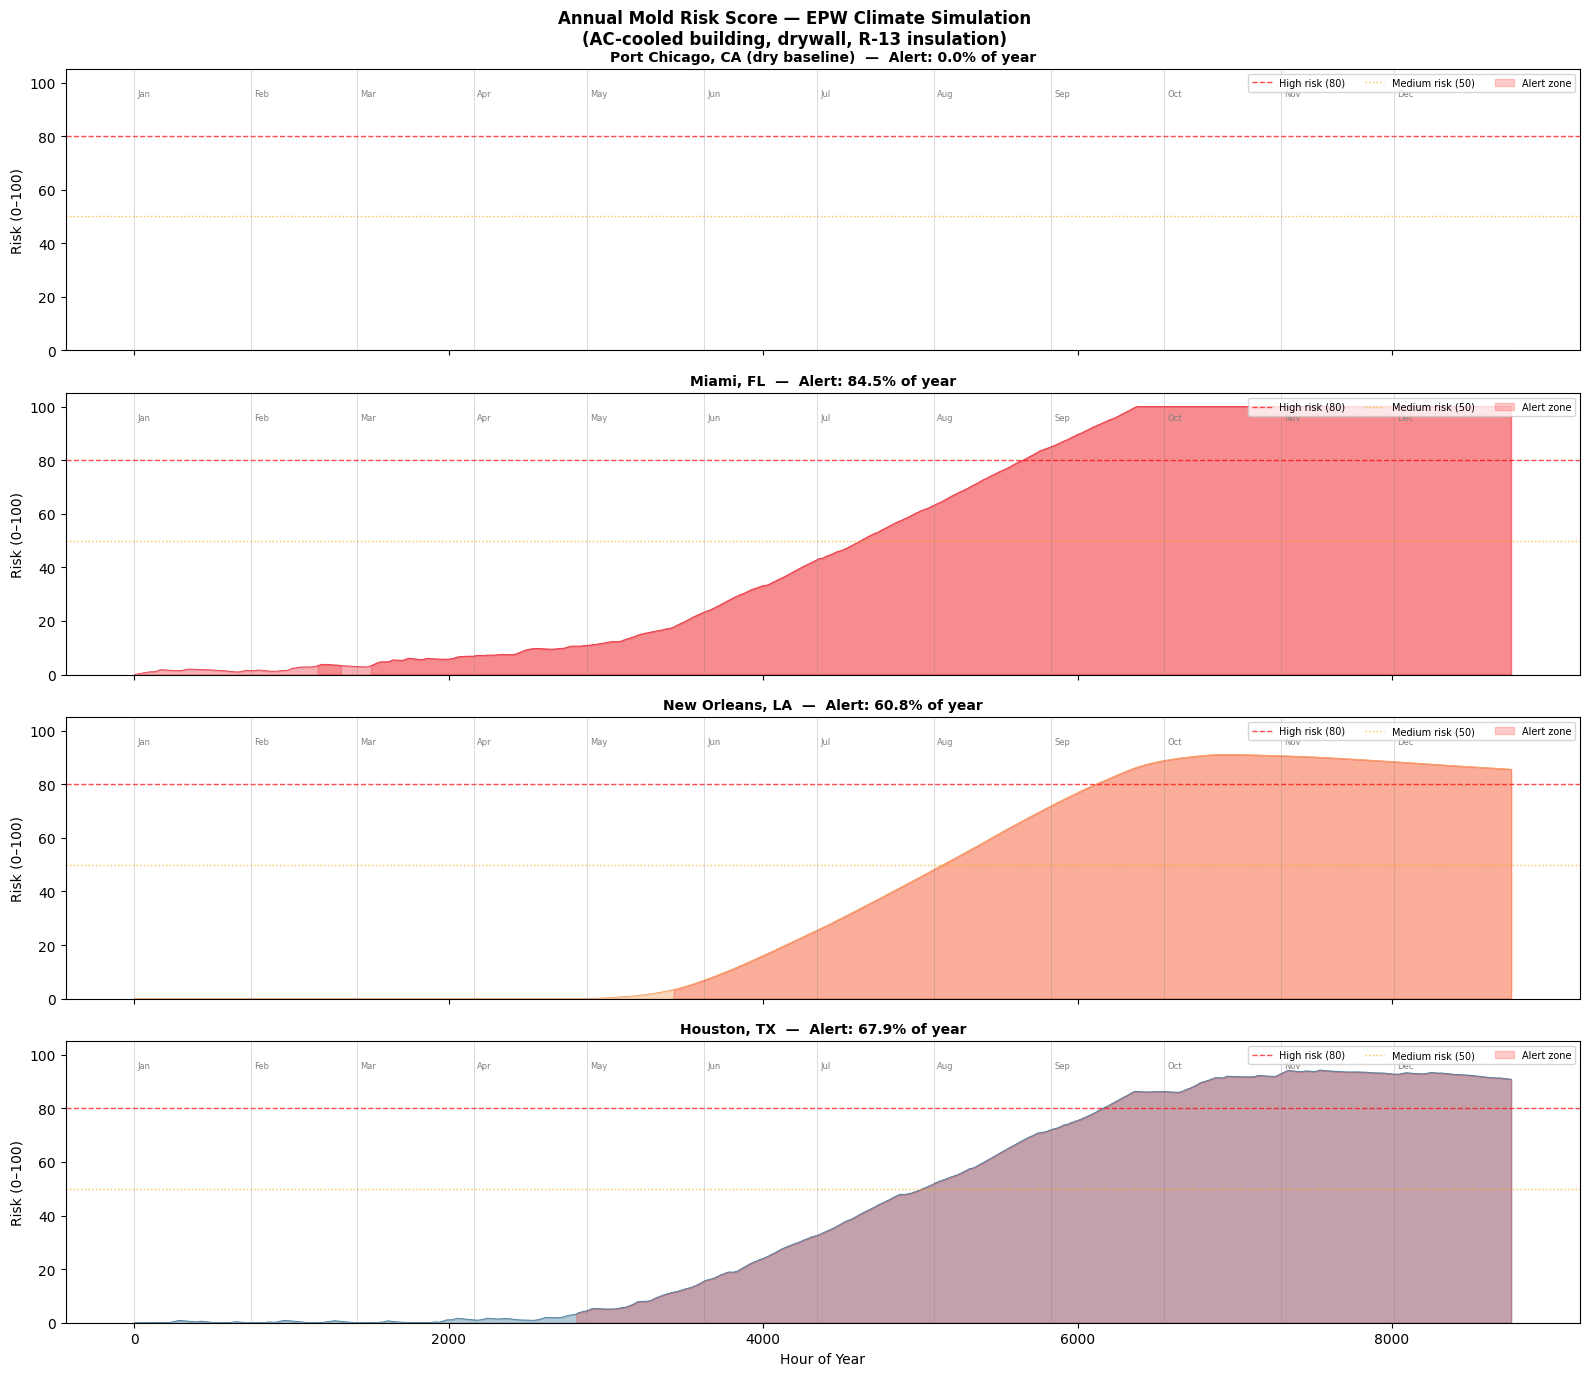

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle("Annual Mold Risk Score — EPW Climate Simulation\n"
             "(AC-cooled building, drywall, R-13 insulation)",
             fontsize=12, fontweight='bold')

city_colors = {
    'USA_CA_Port.Chicago.': '#2a9d8f',
    'USA_FL_Miami.Intl.AP': '#e63946',
    'USA_LA_New.Orleans-N': '#f4a261',
    'USA_TX_Houston-Bush.': '#457b9d',
}
city_labels = {
    'USA_CA_Port.Chicago.': 'Port Chicago, CA (dry baseline)',
    'USA_FL_Miami.Intl.AP': 'Miami, FL',
    'USA_LA_New.Orleans-N': 'New Orleans, LA',
    'USA_TX_Houston-Bush.': 'Houston, TX',
}

for ax, (name, df) in zip(axes, epw_dfs.items()):
    res = simulate_wall_cavity(df, indoor_ac_temp=22.0,
                               insulation_r=13, material='drywall')
    hours = np.arange(8760)
    color = city_colors.get(name, 'steelblue')
    label = city_labels.get(name, name)

    ax.fill_between(hours, res['risk_score'],
                    alpha=0.4, color=color)
    ax.plot(hours, res['risk_score'],
            linewidth=0.6, color=color)
    ax.axhline(80, color='red', linestyle='--',
               linewidth=1, alpha=0.7, label='High risk (80)')
    ax.axhline(50, color='orange', linestyle=':',
               linewidth=1, alpha=0.7, label='Medium risk (50)')
    ax.fill_between(hours, res['risk_score'],
                    where=res['alert'], alpha=0.2,
                    color='red', label='Alert zone')

    pct = res['alert'].mean() * 100
    ax.set_title(f"{label}  —  Alert: {pct:.1f}% of year",
                 fontsize=10, fontweight='bold')
    ax.set_ylabel("Risk (0–100)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=7, loc='upper right', ncol=3)

    # Add month markers
    month_starts = [0,744,1416,2160,2880,3624,4344,5088,5832,6552,7296,8016]
    month_names  = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
    for ms, mn in zip(month_starts, month_names):
        ax.axvline(ms, color='gray', linewidth=0.4, alpha=0.5)
        ax.text(ms+20, 95, mn, fontsize=6, color='gray')

axes[-1].set_xlabel("Hour of Year")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_epw_risk_timeseries.png",
            dpi=150, bbox_inches='tight')
plt.show()

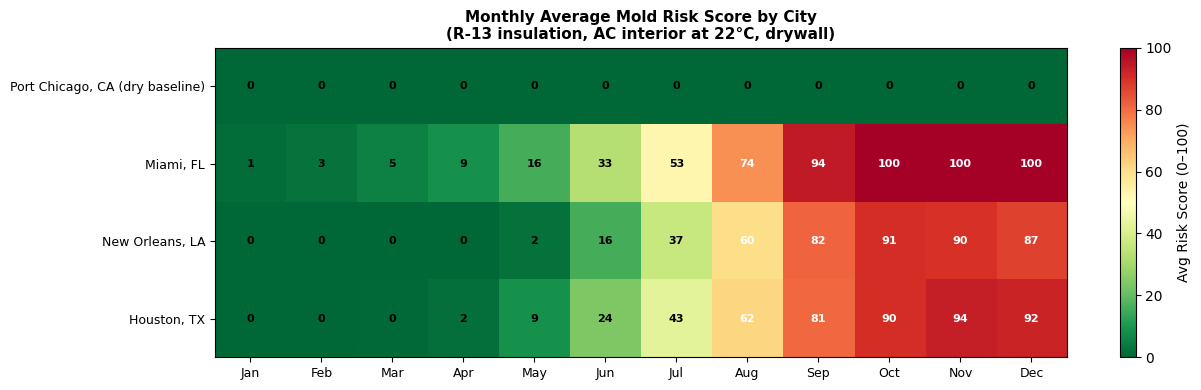

In [6]:
# Break risk score into monthly averages per city
month_hours = [744,672,744,720,744,720,744,744,720,744,720,744]
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_data = {}
for name, df in epw_dfs.items():
    res = simulate_wall_cavity(df, indoor_ac_temp=22.0,
                               insulation_r=13, material='drywall')
    scores = res['risk_score']
    monthly = []
    idx = 0
    for hrs in month_hours:
        monthly.append(scores[idx:idx+hrs].mean())
        idx += hrs
    monthly_data[city_labels.get(name, name)] = monthly

monthly_df = pd.DataFrame(monthly_data, index=month_names).T

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(monthly_df.values, cmap='RdYlGn_r',
               vmin=0, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='Avg Risk Score (0–100)')

ax.set_xticks(range(12))
ax.set_xticklabels(month_names, fontsize=9)
ax.set_yticks(range(len(monthly_df)))
ax.set_yticklabels(monthly_df.index, fontsize=9)
ax.set_title("Monthly Average Mold Risk Score by City\n"
             "(R-13 insulation, AC interior at 22°C, drywall)",
             fontsize=11, fontweight='bold')

for i in range(len(monthly_df)):
    for j in range(12):
        val = monthly_df.values[i, j]
        ax.text(j, i, f"{val:.0f}", ha='center', va='center',
                fontsize=8, fontweight='bold',
                color='white' if val > 55 else 'black')

plt.tight_layout()
plt.savefig(FIG_DIR / "03_monthly_risk_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()

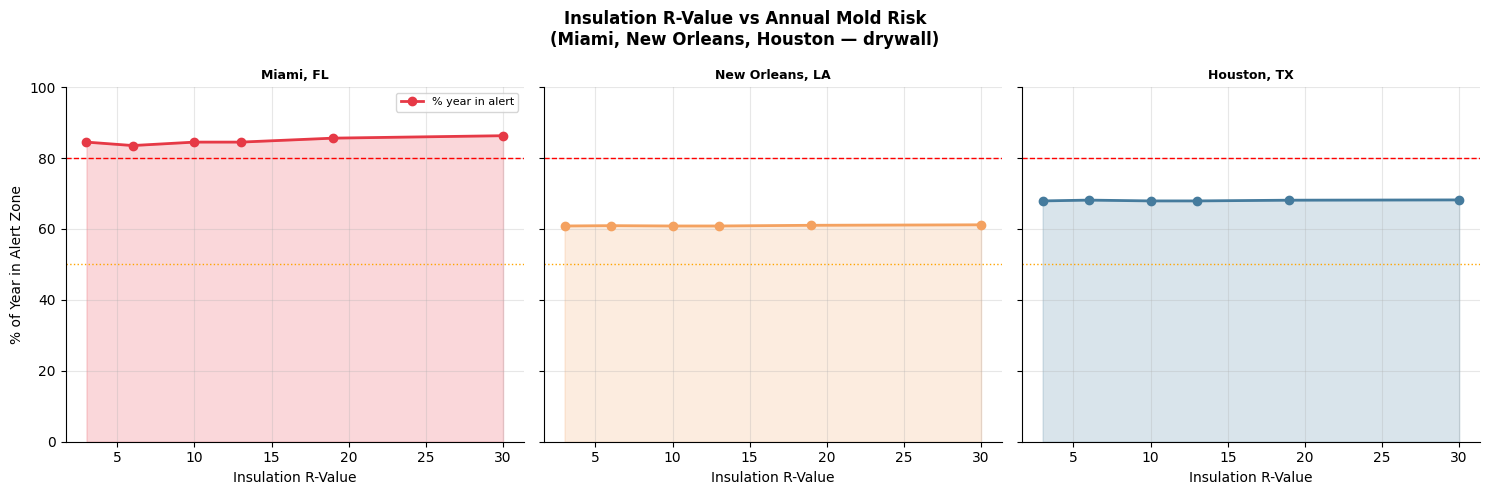

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Insulation R-Value vs Annual Mold Risk\n"
             "(Miami, New Orleans, Houston — drywall)",
             fontsize=12, fontweight='bold')

r_values  = [3, 6, 10, 13, 19, 30]
hot_cities = ['USA_FL_Miami.Intl.AP',
              'USA_LA_New.Orleans-N',
              'USA_TX_Houston-Bush.']

for ax, name in zip(axes, hot_cities):
    pct_alerts = []
    max_risks  = []
    for r in r_values:
        res = simulate_wall_cavity(epw_dfs[name],
                                   indoor_ac_temp=22.0,
                                   insulation_r=r,
                                   material='drywall')
        pct_alerts.append(res['alert'].mean() * 100)
        max_risks.append(res['risk_score'].max())

    color = city_colors.get(name, 'steelblue')
    ax.plot(r_values, pct_alerts, 'o-', color=color,
            linewidth=2, markersize=6, label='% year in alert')
    ax.fill_between(r_values, pct_alerts, alpha=0.2, color=color)
    ax.set_xlabel("Insulation R-Value")
    ax.set_title(city_labels.get(name, name), fontsize=9,
                 fontweight='bold')
    ax.set_ylim(0, 100)
    ax.axhline(50, color='orange', linestyle=':', linewidth=1)
    ax.axhline(80, color='red', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

axes[0].set_ylabel("% of Year in Alert Zone")
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_rvalue_sensitivity.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("=" * 60)
print("  SHIELDNODE — KEY FINDINGS FOR PITCH DECK")
print("=" * 60)

for name, df in epw_dfs.items():
    label = city_labels.get(name, name)
    res6  = simulate_wall_cavity(df, insulation_r=6)
    res13 = simulate_wall_cavity(df, insulation_r=13)

    print(f"\n  {label}")
    print(f"    R-6  (old/poor insulation) : "
          f"{res6['alert'].mean()*100:.0f}% of year at risk  |  "
          f"Peak score: {res6['risk_score'].max():.0f}")
    print(f"    R-13 (code minimum)        : "
          f"{res13['alert'].mean()*100:.0f}% of year at risk  |  "
          f"Peak score: {res13['risk_score'].max():.0f}")

print()
print("  KEY INSIGHT FOR PITCH:")
print("  Even code-compliant R-13 insulation leaves Miami homes")
print("  at mold risk for 84% of the year. Current solutions")
print("  detect mold AFTER it appears. ShieldNode detects the")
print("  conditions 2-4 weeks before germination completes.")
print("=" * 60)

  SHIELDNODE — KEY FINDINGS FOR PITCH DECK

  Port Chicago, CA (dry baseline)
    R-6  (old/poor insulation) : 0% of year at risk  |  Peak score: 0
    R-13 (code minimum)        : 0% of year at risk  |  Peak score: 0

  Miami, FL
    R-6  (old/poor insulation) : 84% of year at risk  |  Peak score: 100
    R-13 (code minimum)        : 84% of year at risk  |  Peak score: 100

  New Orleans, LA
    R-6  (old/poor insulation) : 61% of year at risk  |  Peak score: 79
    R-13 (code minimum)        : 61% of year at risk  |  Peak score: 91

  Houston, TX
    R-6  (old/poor insulation) : 68% of year at risk  |  Peak score: 84
    R-13 (code minimum)        : 68% of year at risk  |  Peak score: 94

  KEY INSIGHT FOR PITCH:
  Even code-compliant R-13 insulation leaves Miami homes
  at mold risk for 84% of the year. Current solutions
  detect mold AFTER it appears. ShieldNode detects the
  conditions 2-4 weeks before germination completes.


In [9]:
# Save EPW simulation results for visualization notebook
import pickle

epw_results = {}
for name, df in epw_dfs.items():
    epw_results[name] = {
        r: simulate_wall_cavity(df, insulation_r=r)
        for r in [6, 13, 19]
    }

with open(PROC_DIR / "epw_risk_results.pkl", 'wb') as f:
    pickle.dump(epw_results, f)

# Save monthly summary
monthly_df.to_parquet(PROC_DIR / "monthly_risk_by_city.parquet")

print("Saved:")
print("  epw_risk_results.pkl")
print("  monthly_risk_by_city.parquet")
print("\nNotebook 3 complete. Ready for Notebook 4 — visualization.")

Saved:
  epw_risk_results.pkl
  monthly_risk_by_city.parquet

Notebook 3 complete. Ready for Notebook 4 — visualization.
